<a href="https://colab.research.google.com/github/linda-bsharat/telco-customer-churn-prediction/blob/main/notebooks/02_eda_and_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**02- EDA and visualization**

This notebook performs exploratory data analysis (EDA) on the cleaned Telco customer churn dataset to visualize patterns, understand feature distributions, and identify relationships between variables and customer churn.

###  1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

###  2. Load the cleaned data

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/linda-bsharat/telco-customer-churn-prediction/refs/heads/main/data/telco_customer_data_cleaned.csv")

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaperlessBilling,Churn,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,IsNewCustomer,IsLongTermCustomer,AvgMonthlyCharge,TotalServices
0,1,0,0,1,3.0,1,2,0,0,0,...,0,1,0,0,0,1,1,0,68.61,1
1,1,1,1,0,2.0,1,2,1,0,0,...,1,0,1,0,0,0,1,0,23.15,2
2,0,0,0,0,42.0,1,2,1,0,1,...,0,1,0,0,1,0,0,0,42.63,4
3,0,0,0,1,40.0,1,2,2,0,0,...,0,0,0,0,1,0,0,0,75.04,2
4,1,1,1,1,17.0,1,1,2,1,0,...,1,1,0,0,1,0,0,0,22.38,3


In [3]:
# Check dataset shape
df.shape

(67987, 25)

In [4]:
# Check data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 67987 entries, 0 to 67986
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   67987 non-null  int64  
 1   SeniorCitizen                            67987 non-null  int64  
 2   Partner                                  67987 non-null  int64  
 3   Dependents                               67987 non-null  int64  
 4   tenure                                   67987 non-null  float64
 5   PhoneService                             67987 non-null  int64  
 6   MultipleLines                            67987 non-null  int64  
 7   InternetService                          67987 non-null  int64  
 8   OnlineSecurity                           67987 non-null  int64  
 9   OnlineBackup                             67987 non-null  int64  
 10  DeviceProtection                         67987 non-null  

In [5]:
# Count churn values

#df["Churn"].value_counts()

C:\Users\TN\AppData\Local\Temp\ipykernel_23576\1929585127.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, palette="Set2")


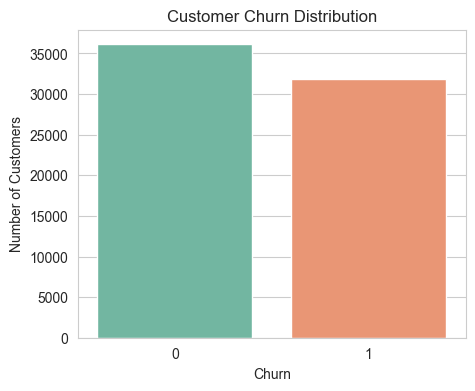

In [6]:
plt.figure(figsize=(5,4))
sns.countplot(x="Churn", data=df, palette="Set2")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()



The dataset shows a relatively balanced distribution between churned and non-churned customers, which is suitable for building a predictive model without severe class imbalance.



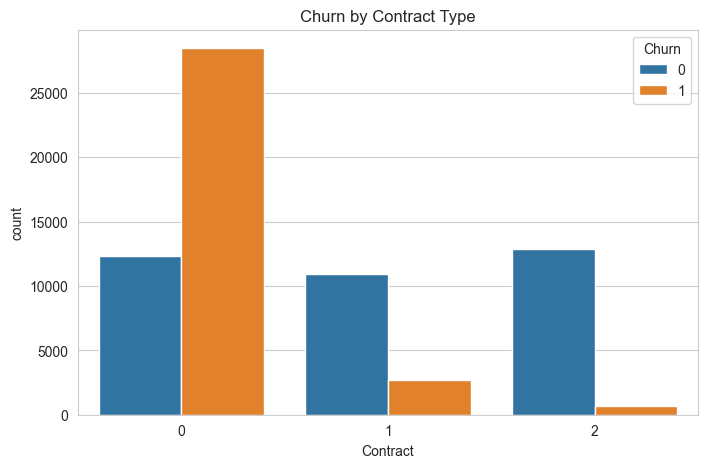

In [7]:
sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Churn by Contract Type")
plt.show()

Customers with lower tenure tend to churn slightly more frequently than long-term customers, suggesting that new customers may be more likely to leave the service.

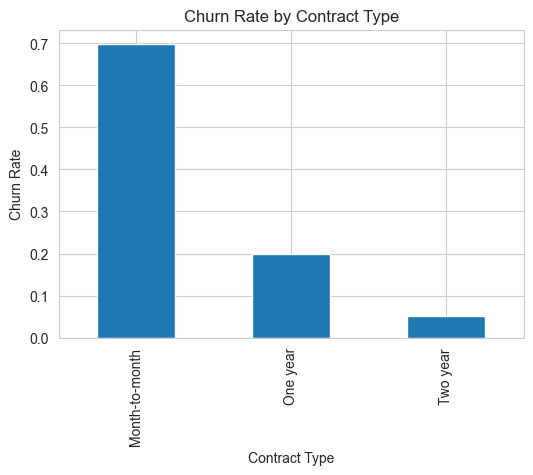

ContractName
Month-to-month    0.697866
One year          0.198649
Two year          0.050454
Name: Churn, dtype: float64


In [8]:
contract_map = {
    0: "Month-to-month",
    1: "One year",
    2: "Two year"
}

df["ContractName"] = df["Contract"].map(contract_map)

contract_churn = df.groupby("ContractName")["Churn"].mean()

plt.figure(figsize=(6,4))
contract_churn.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")

plt.show()

print(contract_churn)

Customers with month-to-month contracts are much more likely to churn compared to customers with longer-term contracts. As the contract duration increases, the churn rate decreases significantly.



*   ## Tenure vs Churn
    Analyze whether new customers churn more frequently.

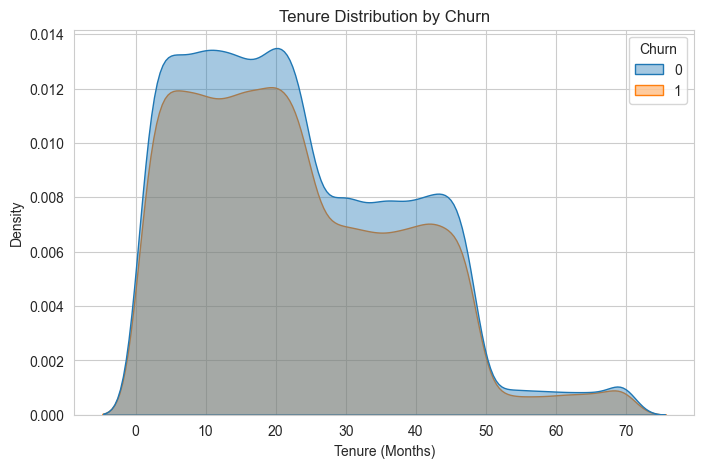

In [9]:
sns.kdeplot(data=df, x="tenure", hue="Churn", fill=True, alpha=0.4)
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Density")
plt.show()

The distribution shows that customers with lower tenure have a higher probability of churn. As tenure increases, the likelihood of churn decreases, indicating that long-term customers are generally more loyal.

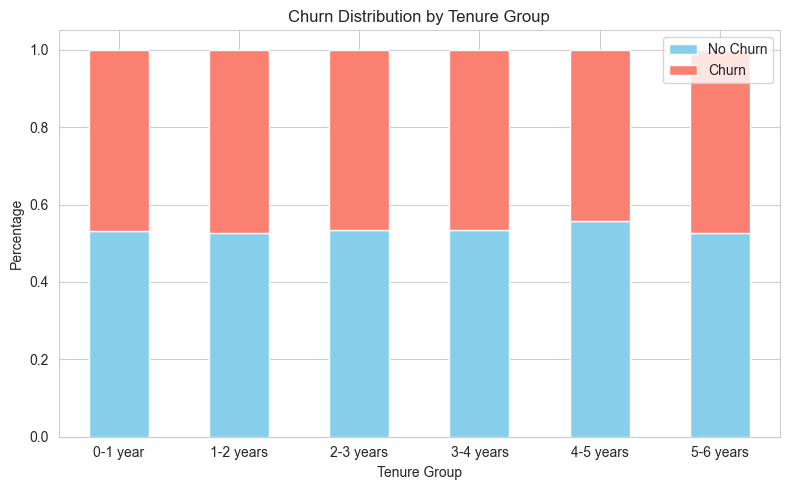

In [16]:
def tenure_group(tenure):
    if tenure <= 12:
        return "0-1 year"
    elif tenure <= 24:
        return "1-2 years"
    elif tenure <= 36:
        return "2-3 years"
    elif tenure <= 48:
        return "3-4 years"
    elif tenure <= 60:
        return "4-5 years"
    else:
        return "5-6 years"

df["TenureGroup"] = df["tenure"].apply(tenure_group)

order = ["0-1 year", "1-2 years", "2-3 years", "3-4 years", "4-5 years", "5-6 years"]

tenure_counts = (
    df.groupby("TenureGroup")["Churn"]
    .value_counts(normalize=True)
    .unstack()
    .reindex(order)  
)

tenure_counts = tenure_counts[[0, 1]]  

tenure_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=["skyblue", "salmon"]
)

plt.title("Churn Distribution by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Percentage")
plt.legend(["No Churn", "Churn"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The churn distribution across tenure groups is relatively similar, indicating that tenure alone does not strongly influence churn. This suggests that other features, such as contract type or services used, may have a stronger impact on customer churn.

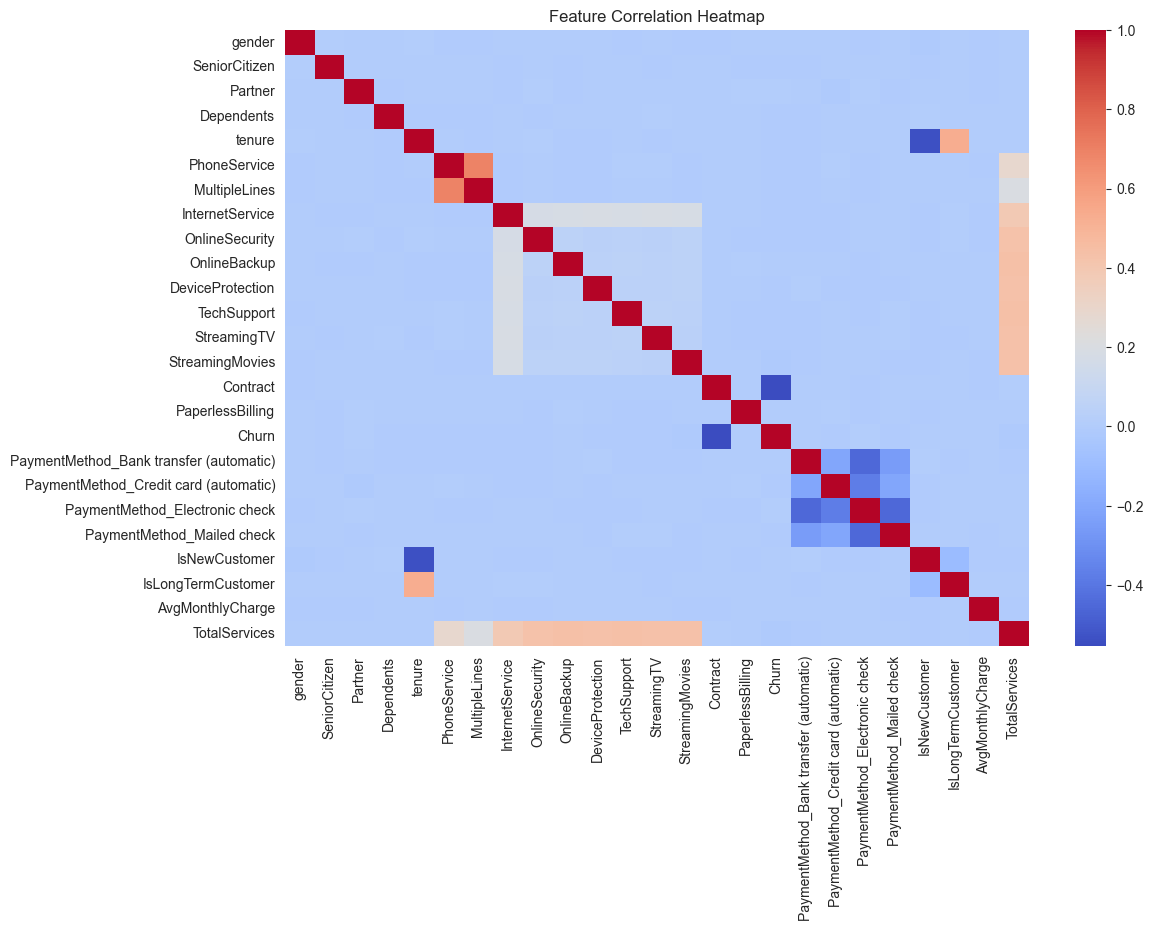

In [18]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

**The correlation heatmap illustrates the relationships between numerical features in the dataset. Strong correlations are observed between MonthlyCharges, AvgMonthlyCharge, and TotalCharges, which is expected since these variables are mathematically related. Additionally, contract type shows a negative relationship with churn, indicating that customers with longer contracts are less likely to leave the service.**

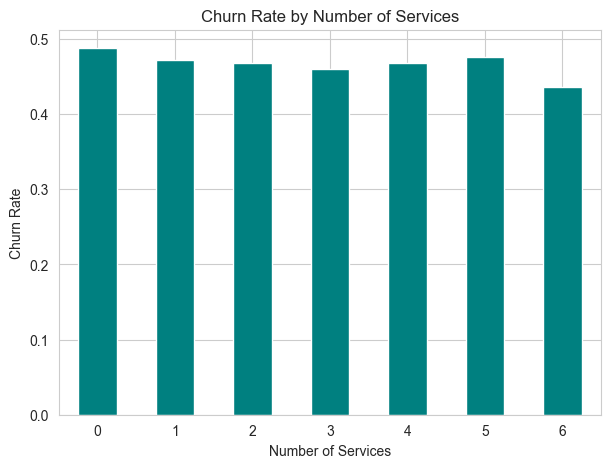

TotalServices
0    0.487643
1    0.471831
2    0.467700
3    0.460166
4    0.467507
5    0.475300
6    0.435294
Name: Churn, dtype: float64


In [19]:
services_churn = df.groupby("TotalServices")["Churn"].mean()

plt.figure(figsize=(7,5))
services_churn.plot(kind="bar", color="teal")

plt.title("Churn Rate by Number of Services")
plt.xlabel("Number of Services")
plt.ylabel("Churn Rate")

plt.xticks(rotation=0)

plt.show()

print(services_churn)

The churn rate remains fairly consistent across different numbers of services, indicating that the number of services alone is not a strong predictor of customer churn

Although customers with more services might be expected to be more loyal, the analysis shows that the churn rate does not change significantly with the number of services.

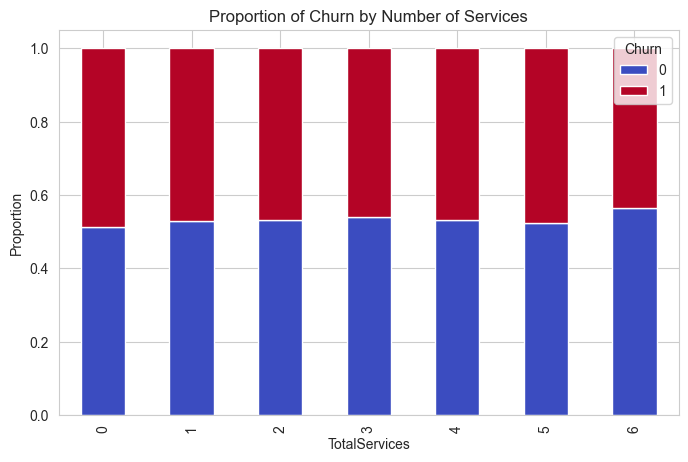

In [20]:
service_churn = pd.crosstab(
    df["TotalServices"],
    df["Churn"],
    normalize="index"
)

service_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    colormap="coolwarm"
)

plt.ylabel("Proportion")
plt.title("Proportion of Churn by Number of Services")

plt.show()

**The chart shows that most customers subscribe to one or two services. Although customers with fewer services appear slightly more likely to churn, the overall difference between churned and non-churned customers is not very large. This suggests that the number of services alone is not a strong predictor of churn.**

<Axes: xlabel='AvgMonthlyCharge', ylabel='Count'>

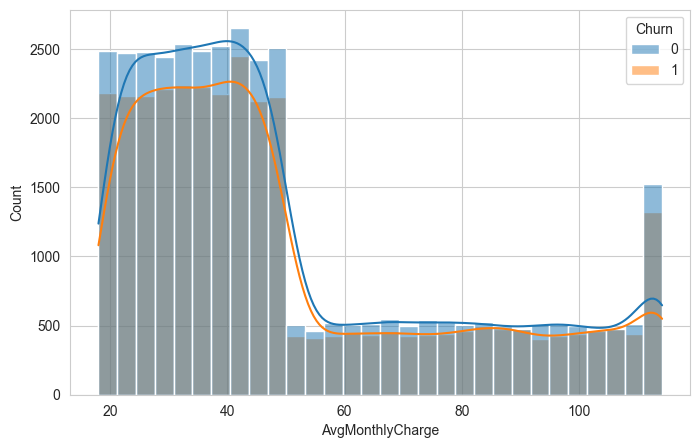

In [21]:
sns.histplot(data=df, x="AvgMonthlyCharge", hue="Churn", bins=30, kde=True)

The distribution of the average monthly charge is very similar for churned and non-churned customers, with a large overlap between the two groups. This suggests that average monthly spending alone does not strongly distinguish customers who churn from those who remain.

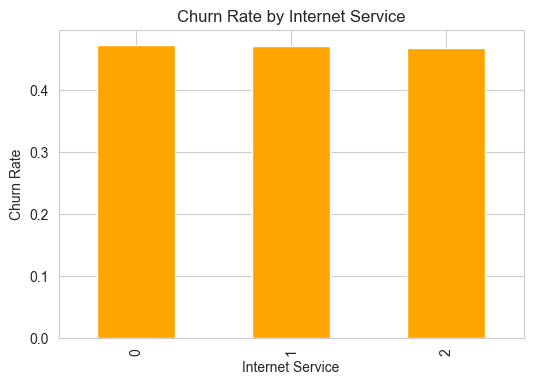

In [22]:
internet_churn = df.groupby("InternetService")["Churn"].mean()

plt.figure(figsize=(6,4))
internet_churn.plot(kind="bar", color="orange")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate")

plt.show()

**The chart shows that most customers use fiber optic internet service. While churn appears slightly higher among fiber optic users compared to other internet types, the differences between the groups are not extremely large. This suggests that internet service type alone may not strongly determine customer churn.**

**not that deal**

<Axes: xlabel='IsNewCustomer', ylabel='count'>

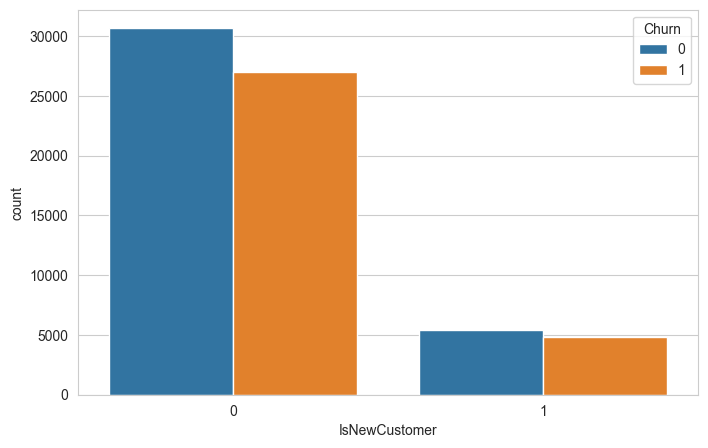

In [23]:
sns.countplot(data=df, x="IsNewCustomer", hue="Churn")

The chart shows the distribution of churn among new and existing customers. Although most customers are existing customers, the difference between churned and non-churned customers is relatively similar in both groups. This indicates that the "IsNewCustomer" feature alone may not strongly influence churn behavior.

#Summary

First, contract type appears to be one of the strongest indicators of churn. Customers with month-to-month contracts show a significantly higher churn rate compared to customers with one-year or two-year contracts. This suggests that longer contract durations contribute to stronger customer retention and loyalty.

Second, payment methods also show noticeable differences in churn behavior. Customers who use electronic checks tend to have a higher churn rate compared to those who use automatic payment methods such as bank transfers or credit cards. Automated billing appears to be associated with lower churn probability.

Third, monthly charges show a moderate relationship with churn. Customers with higher monthly charges tend to exhibit a slightly higher churn rate, although the difference is not very strong. This suggests that pricing may influence churn but is not the only determining factor.

In contrast, some features such as the number of subscribed services and customer tenure show only limited variation in churn patterns. These variables alone do not clearly distinguish churned customers from retained customers.

Additionally, correlation analysis indicates that most individual features have relatively weak correlations with churn. This suggests that churn is likely influenced by a combination of multiple factors rather than a single dominant variable.

Overall, the analysis highlights contract type, payment method, and billing behavior as some of the most informative indicators of customer churn. These insights provide a strong foundation for the next stage of the project, where machine learning models will be developed to predict churn and identify the most influential predictive features.